# CDS 2413 – Introduction to Data Science
## Project Deliverable 2 (D2) — Machine Learning Model Report
### Dataset: Restaurant Tips (Seaborn Built-in)

---
**Student Name:** *(fill in)*  
**Student ID:** *(fill in)*  
**Semester:** 202520

---

| Variable | Role | Type |
|---|---|---|
| `tip` | Dependent Variable (DV / y) | Numerical / Categorical |
| `total_bill` | Independent Variable (IV / X) | Numerical |
| `size` | Independent Variable (IV / X) | Numerical |
| `sex` | Independent Variable (IV / X) | Categorical (Binary) |
| `smoker` | Independent Variable (IV / X) | Categorical (Binary) |
| `time` | Independent Variable (IV / X) | Categorical (Binary) |
| `day` | Independent Variable (IV / X) | Categorical (Nominal) |

---
# CLO3 — Section 1: Preprocessing (5 Points)

### Cell 1 — Data Collection
> **📸 SCREENSHOT → Word doc: Preprocessing › Data Collection**

In [ ]:
# ============================================================
# CELL 1: IMPORTING THE LIBRARIES AND LOADING THE DATASET
# (Aligned with Lab syntax: import → load → print)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score,
                              classification_report, confusion_matrix)
from sklearn.cluster import KMeans
import scipy.cluster.hierarchy as sch
import warnings
warnings.filterwarnings('ignore')

# Load the Tips dataset (built-in, equivalent to pd.read_csv)
dataset = sns.load_dataset('tips')

print('===== DATA COLLECTION =====')
print(f'Dataset Shape  : {dataset.shape}')
print(f'Rows           : {dataset.shape[0]}')
print(f'Columns        : {dataset.shape[1]}')
print('\nFirst 10 rows:')
print(dataset.head(10))
print('\nColumn Names:', list(dataset.columns))
print('\nDependent Variable   : tip (numerical)')
print('Independent Variables:', ['total_bill','size','sex','smoker','day','time'])
print('\nData Types:')
print(dataset.dtypes)

===== DATA COLLECTION =====
Dataset Shape  : (244, 7)
Rows           : 244
Columns        : 7

First 10 rows:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
5       25.29  4.71    Male     No  Sun  Dinner     4
6        8.77  2.00    Male     No  Sun  Dinner     2
7       26.88  3.12    Male     No  Sun  Dinner     4
8       15.04  1.96    Male     No  Sun  Dinner     2
9       14.78  3.23    Male     No  Sun  Dinner     2

Column Names: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

Dependent Variable   : tip (numerical)
Independent Variables: ['total_bill', 'size', 'sex', 'smoker', 'day', 'time']

Data Types:
total_bill     float64
tip            float64
sex           category
smoker        categ

### Cell 2 — Data Cleaning
> **📸 SCREENSHOT → Word doc: Preprocessing › Data Cleaning**

In [ ]:
# ============================================================
# CELL 2: DATA CLEANING
# Strategy: fill missing values with mean/mode, remove
# duplicates, detect & remove outliers using IQR method
# ============================================================

print('===== DATA CLEANING =====')

print('\n[1] Missing Values Before Cleaning:')
print(dataset.isnull().sum())


for col in dataset.select_dtypes(include=np.number).columns:
    dataset[col].fillna(dataset[col].mean(), inplace=True)

# Step 3: Fill categorical missing values with mode
for col in dataset.select_dtypes(include='object').columns:
    dataset[col].fillna(dataset[col].mode()[0], inplace=True)

print('\n[2] Missing Values After Cleaning:')
print(dataset.isnull().sum())


print(f'\n[3] Duplicate Rows Found   : {dataset.duplicated().sum()}')
dataset.drop_duplicates(inplace=True)
print(f'    Duplicates After Removal : {dataset.duplicated().sum()}')


print('\n[4] Outlier Detection (IQR Method):')
outlier_indices = set()
for col in ['total_bill', 'tip', 'size']:
    Q1  = dataset[col].quantile(0.25)
    Q3  = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = dataset[(dataset[col] < lower_bound) | (dataset[col] > upper_bound)]
    print(f'    {col}: {len(outliers)} outlier(s) | '
          f'Lower={lower_bound:.2f}, Upper={upper_bound:.2f}')
    outlier_indices.update(outliers.index.tolist())

print(f'\n[5] Total Unique Outlier Rows: {len(outlier_indices)}')
dataset_clean = dataset.drop(index=list(outlier_indices)).reset_index(drop=True)
print(f'    Dataset size after removing outliers: {dataset_clean.shape}')

===== DATA CLEANING =====

[1] Missing Values Before Cleaning:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

[2] Missing Values After Cleaning:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

[3] Duplicate Rows Found   : 1
    Duplicates After Removal : 0

[4] Outlier Detection (IQR Method):
    total_bill: 9 outlier(s) | Lower=-2.81, Upper=40.37
    tip: 8 outlier(s) | Lower=-0.36, Upper=5.94
    size: 9 outlier(s) | Lower=0.50, Upper=4.50

[5] Total Unique Outlier Rows: 20
    Dataset size after removing outliers: (223, 7)


### Cell 3 — Treating Categorical Variables
> **📸 SCREENSHOT → Word doc: Preprocessing › Treating the Categorical Variables**

In [ ]:


print('===== CATEGORICAL VARIABLE ENCODING =====')

print('\nCategorical columns and their unique values:')
cat_cols = dataset_clean.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    print(f'  {col:<10}: {list(dataset_clean[col].unique())}  -> Binary/Nominal')

# Label Encoding for binary columns (sex, smoker, time)
# Justification: Only 2 unique values each — Label Encoding (0/1) is sufficient
le = LabelEncoder()
dataset_encoded = dataset_clean.copy()
binary_cols = ['sex', 'smoker', 'time']
for col in binary_cols:
    dataset_encoded[col] = le.fit_transform(dataset_encoded[col])
    print(f'\n  Label Encoded [{col}]: '
          f'{dict(zip(le.classes_, le.transform(le.classes_)))}')

# One-Hot Encoding for 'day' (4 nominal categories)
# Justification: Nominal with >2 values — prevents false ordinal assumption
dataset_encoded = pd.get_dummies(dataset_encoded, columns=['day'], drop_first=True)
print('\n  One-Hot Encoded [day]: new columns →',
      [c for c in dataset_encoded.columns if 'day_' in c])

print('\nFinal encoded dataset shape:', dataset_encoded.shape)
print('\nFirst 5 rows of encoded dataset:')
print(dataset_encoded.head())

===== CATEGORICAL VARIABLE ENCODING =====

Categorical columns and their unique values:
  sex       : ['Female', 'Male']  -> Binary/Nominal
  smoker    : ['No', 'Yes']  -> Binary/Nominal
  day       : ['Sun', 'Sat', 'Thur', 'Fri']  -> Binary/Nominal
  time      : ['Dinner', 'Lunch']  -> Binary/Nominal

  Label Encoded [sex]: {'Female': np.int64(0), 'Male': np.int64(1)}

  Label Encoded [smoker]: {'No': np.int64(0), 'Yes': np.int64(1)}

  Label Encoded [time]: {'Dinner': np.int64(0), 'Lunch': np.int64(1)}

  One-Hot Encoded [day]: new columns → ['day_Fri', 'day_Sat', 'day_Sun']

Final encoded dataset shape: (223, 9)

First 5 rows of encoded dataset:
   total_bill   tip  sex  smoker  time  size  day_Fri  day_Sat  day_Sun
0       16.99  1.01    0       0     0     2    False    False     True
1       10.34  1.66    1       0     0     3    False    False     True
2       21.01  3.50    1       0     0     3    False    False     True
3       23.68  3.31    1       0     0     2    False  

### Cell 4 — Splitting the Dataset
> **📸 SCREENSHOT → Word doc: Preprocessing › Splitting the Dataset**

In [ ]:


print('===== SPLITTING THE DATASET =====')

# Independent variables (X) = all columns except tip
# Dependent variable  (y) = tip
X = dataset_encoded.iloc[:, dataset_encoded.columns != 'tip'].values
y = dataset_encoded['tip'].values

print(f'Independent Variables (X) shape : {X.shape}')
print(f'Dependent Variable    (y) shape : {y.shape}')
print(f'Feature columns: {list(dataset_encoded.columns[dataset_encoded.columns != "tip"])}')

# Split: 80% training, 20% testing (test_size=0.2, random_state=0 — lab standard)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

print(f'\nTraining set size : {X_train.shape[0]} rows (80%)')
print(f'Testing  set size : {X_test.shape[0]}  rows (20%)')
print('\nReason for 80/20 split:')
print('  - 80% training provides sufficient data for the model to learn patterns.')
print('  - 20% testing gives an unbiased evaluation on unseen data.')
print('  - Splitting prevents overfitting and ensures generalizability.')

===== SPLITTING THE DATASET =====
Independent Variables (X) shape : (223, 8)
Dependent Variable    (y) shape : (223,)
Feature columns: ['total_bill', 'sex', 'smoker', 'time', 'size', 'day_Fri', 'day_Sat', 'day_Sun']

Training set size : 178 rows (80%)
Testing  set size : 45  rows (20%)

Reason for 80/20 split:
  - 80% training provides sufficient data for the model to learn patterns.
  - 20% testing gives an unbiased evaluation on unseen data.
  - Splitting prevents overfitting and ensures generalizability.


### Cell 5 — Feature Scaling
> **📸 SCREENSHOT → Word doc: Preprocessing › Featuring the Dataset**

In [ ]:

print('===== FEATURE SCALING =====')
print('Technique Used : StandardScaler (Z-score Standardisation)')
print('Formula        : z = (x - mean) / std')
print('Reason         : Features have different scales (total_bill: $3–$50 vs size: 1–6).')
print('                 Standardisation brings all features to mean=0, std=1.')
print('                 Required for Ridge, Lasso, ElasticNet, KNN, SVM.')

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)

print(f'\nX_train after scaling — mean : {X_train[:, 0].mean():.6f}  (≈ 0)')
print(f'X_train after scaling — std  : {X_train[:, 0].std():.6f}  (≈ 1)')
print('\nScaling applied to X_train (fit+transform) and X_test (transform only).')
print('Note: Scaler is fit ONLY on X_train to prevent data leakage.')

===== FEATURE SCALING =====
Technique Used : StandardScaler (Z-score Standardisation)
Formula        : z = (x - mean) / std
Reason         : Features have different scales (total_bill: $3–$50 vs size: 1–6).
                 Standardisation brings all features to mean=0, std=1.
                 Required for Ridge, Lasso, ElasticNet, KNN, SVM.

X_train after scaling — mean : -0.000000  (≈ 0)
X_train after scaling — std  : 1.000000  (≈ 1)

Scaling applied to X_train (fit+transform) and X_test (transform only).
Note: Scaler is fit ONLY on X_train to prevent data leakage.


---
# CLO3 — Section 2: Regression Model (7 Points)

### Cell 6 — Building All 5 Regression Models + Comparison
> **📸 SCREENSHOT → Word doc: Regression › Building the Regression Model**

In [ ]:


results = []
predicted_values = {}

# Polynomial features (degree=2) — prepared once, used for Poly model
poly_features   = PolynomialFeatures(degree=2)
X_poly_train    = poly_features.fit_transform(X_train)
X_poly_test     = poly_features.transform(X_test)

# ------------------------------------------------------------------
# 1. LINEAR REGRESSION
# ------------------------------------------------------------------
regressor = LinearRegression()
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)
results.append({'Model': 'Linear Regression', 'MSE': round(mse,4), 'R2': round(r2,4)})
predicted_values['Linear Regression'] = y_pred
print(f'[1] Linear Regression          | MSE: {mse:.4f} | R²: {r2:.4f} ({r2*100:.2f}%)')

# ------------------------------------------------------------------
# 2. POLYNOMIAL REGRESSION (Degree 2)
# ------------------------------------------------------------------
regressor_poly = LinearRegression()
regressor_poly.fit(X_poly_train, y_train)
y_pred_poly = regressor_poly.predict(X_poly_test)
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly  = r2_score(y_test, y_pred_poly)
results.append({'Model': 'Polynomial Regression (Degree 2)', 'MSE': round(mse_poly,4), 'R2': round(r2_poly,4)})
predicted_values['Polynomial Regression (Degree 2)'] = y_pred_poly
print(f'[2] Polynomial Regression (d=2)| MSE: {mse_poly:.4f} | R²: {r2_poly:.4f} ({r2_poly*100:.2f}%)')

# ------------------------------------------------------------------
# 3. RIDGE REGRESSION (L2)
# ------------------------------------------------------------------
regressor_ridge = Ridge(alpha=1.0)
regressor_ridge.fit(X_train, y_train)
y_pred_ridge = regressor_ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge  = r2_score(y_test, y_pred_ridge)
results.append({'Model': 'Ridge Regression', 'MSE': round(mse_ridge,4), 'R2': round(r2_ridge,4)})
predicted_values['Ridge Regression'] = y_pred_ridge
print(f'[3] Ridge Regression           | MSE: {mse_ridge:.4f} | R²: {r2_ridge:.4f} ({r2_ridge*100:.2f}%)')

# ------------------------------------------------------------------
# 4. LASSO REGRESSION (L1)
# ------------------------------------------------------------------
regressor_lasso = Lasso(alpha=0.1)
regressor_lasso.fit(X_train, y_train)
y_pred_lasso = regressor_lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso  = r2_score(y_test, y_pred_lasso)
results.append({'Model': 'Lasso Regression', 'MSE': round(mse_lasso,4), 'R2': round(r2_lasso,4)})
predicted_values['Lasso Regression'] = y_pred_lasso
print(f'[4] Lasso Regression           | MSE: {mse_lasso:.4f} | R²: {r2_lasso:.4f} ({r2_lasso*100:.2f}%)')

# ------------------------------------------------------------------
# 5. ELASTIC NET REGRESSION (L1 + L2)
# ------------------------------------------------------------------
regressor_enet = ElasticNet(alpha=0.1, l1_ratio=0.5)
regressor_enet.fit(X_train, y_train)
y_pred_enet = regressor_enet.predict(X_test)
mse_enet = mean_squared_error(y_test, y_pred_enet)
r2_enet  = r2_score(y_test, y_pred_enet)
results.append({'Model': 'Elastic Net Regression', 'MSE': round(mse_enet,4), 'R2': round(r2_enet,4)})
predicted_values['Elastic Net Regression'] = y_pred_enet
print(f'[5] Elastic Net Regression     | MSE: {mse_enet:.4f} | R²: {r2_enet:.4f} ({r2_enet*100:.2f}%)')

# ------------------------------------------------------------------
# COMPARISON TABLE — select best by highest R²
# ------------------------------------------------------------------
comparison_results = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
print('\n===== Comparison of Regression Models =====')
print(comparison_results.to_string(index=False))

best_model_name = comparison_results.iloc[0]['Model']
best_model_r2   = comparison_results.iloc[0]['R2']
best_model_mse  = comparison_results.iloc[0]['MSE']
print(f'\nBest-Fit Model : {best_model_name}')
print(f'R-squared      : {best_model_r2} ({best_model_r2*100:.2f}%)')
print(f'Mean Squared Error: {best_model_mse}')

[1] Linear Regression          | MSE: 0.6818 | R²: 0.2793 (27.93%)
[2] Polynomial Regression (d=2)| MSE: 1.5071 | R²: -0.5931 (-59.31%)
[3] Ridge Regression           | MSE: 0.6793 | R²: 0.2819 (28.19%)
[4] Lasso Regression           | MSE: 0.6324 | R²: 0.3315 (33.15%)
[5] Elastic Net Regression     | MSE: 0.6361 | R²: 0.3276 (32.76%)

===== Comparison of Regression Models =====
                           Model    MSE      R2
                Lasso Regression 0.6324  0.3315
          Elastic Net Regression 0.6361  0.3276
                Ridge Regression 0.6793  0.2819
               Linear Regression 0.6818  0.2793
Polynomial Regression (Degree 2) 1.5071 -0.5931

Best-Fit Model : Lasso Regression
R-squared      : 0.3315 (33.15%)
Mean Squared Error: 0.6324


### Cell 7 — Regression Equation + Observed vs Predicted Plot
> **📸 SCREENSHOT output text + chart → Word doc: Regression › Building the Regression Model (Visualisation)**

===== REGRESSION EQUATIONS =====

[Linear Regression]
  Intercept    : 2.8162
  Coefficients : [ 0.66042193 -0.029353    0.00743707 -0.04126392  0.0205631  -0.05732527
 -0.10424243  0.06196214]
  Equation: tip = 2.8162 + 0.6604*total_bill - 0.0294*sex + 0.0074*smoker - 0.0413*time + 0.0206*size - 0.0573*day_Fri - 0.1042*day_Sat + 0.0620*day_Sun

[Ridge Regression — L2 Regularisation]
  Intercept    : 2.8162
  Coefficients : [ 0.65539607 -0.02914407  0.00790666 -0.03768209  0.02301836 -0.05525589
 -0.09922469  0.06598375]

[Lasso Regression — L1 Regularisation]
  Intercept    : 2.8162
  Coefficients : [ 0.57104967 -0.         -0.         -0.          0.         -0.
 -0.          0.04768469]

[Elastic Net Regression — L1+L2]
  Intercept    : 2.8162
  Coefficients : [ 0.58154184 -0.         -0.          0.          0.0125166  -0.
 -0.          0.08997685]

[Polynomial Regression (Degree 2)]
  Intercept    : 3.4464
  Coefficients : [ 7.56803875e-17  8.00601299e-01 -2.26701858e-02  5.167778

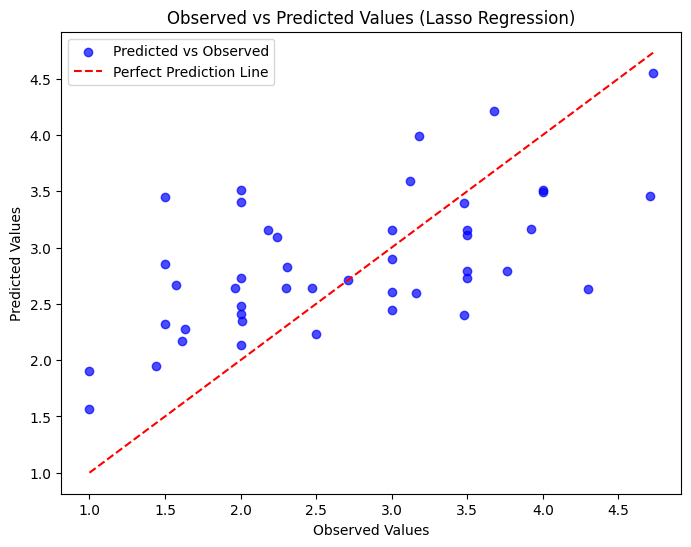

Note: Points close to the red line indicate accurate predictions.


In [ ]:
# ============================================================
# CELL 7: PRINT REGRESSION EQUATIONS + OBSERVED vs PREDICTED
# (Aligned with lab: print coef_ and intercept_, show equation)
# ============================================================

feature_names = [c for c in dataset_encoded.columns if c != 'tip']

print('===== REGRESSION EQUATIONS =====')

# Linear Regression Equation
print('\n[Linear Regression]')
print(f'  Intercept    : {regressor.intercept_:.4f}')
print(f'  Coefficients : {regressor.coef_}')
eq = f'tip = {regressor.intercept_:.4f}'
for name, coef in zip(feature_names, regressor.coef_):
    sign = '+' if coef >= 0 else '-'
    eq += f' {sign} {abs(coef):.4f}*{name}'
print(f'  Equation: {eq}')

# Ridge Equation
print('\n[Ridge Regression — L2 Regularisation]')
print(f'  Intercept    : {regressor_ridge.intercept_:.4f}')
print(f'  Coefficients : {regressor_ridge.coef_}')

# Lasso Equation
print('\n[Lasso Regression — L1 Regularisation]')
print(f'  Intercept    : {regressor_lasso.intercept_:.4f}')
print(f'  Coefficients : {regressor_lasso.coef_}')

# Elastic Net Equation
print('\n[Elastic Net Regression — L1+L2]')
print(f'  Intercept    : {regressor_enet.intercept_:.4f}')
print(f'  Coefficients : {regressor_enet.coef_}')

# Polynomial Equation
print('\n[Polynomial Regression (Degree 2)]')
print(f'  Intercept    : {regressor_poly.intercept_:.4f}')
print(f'  Coefficients : {regressor_poly.coef_}')

# Observed vs Predicted — best model
y_pred_best = predicted_values[best_model_name]

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.7, color='blue', label='Predicted vs Observed')
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         color='red', linestyle='--', label='Perfect Prediction Line')
plt.title(f'Observed vs Predicted Values ({best_model_name})')
plt.xlabel('Observed Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()
print('Note: Points close to the red line indicate accurate predictions.')

### Cell 8 — Hand-Drawn Regression Equation Section
> **📸 SCREENSHOT the table output → Word doc: Regression › Deriving the Regression Equation**  
> ✏️ After running: copy table + equation to paper, substitute values manually, draw scatter graph by hand, scan & paste into Word doc.

In [ ]:
# ============================================================
# CELL 8: DERIVING THE REGRESSION EQUATION (HAND-DRAWN PART)
# Step: Print equation + 5 random records
# Student must: substitute values manually on paper,
# draw scatter plot (pen & paper), scan and paste in Word doc.
# ============================================================

print('=' * 65)
print('  FINAL REGRESSION EQUATION (from best-fit model)')
print('=' * 65)
print(f'  Model: {best_model_name}')
print(f'  Intercept: {regressor.intercept_:.4f}')
print('\n  tip = ' + f'{regressor.intercept_:.4f}')
for name, coef in zip(feature_names, regressor.coef_):
    sign = '+' if coef >= 0 else '-'
    print(f'        {sign} {abs(coef):.4f} * {name}')

print('\n' + '=' * 65)
print('  5 RANDOM RECORDS — substitute into equation on paper')
print('=' * 65)

np.random.seed(42)
sample_5_idx = np.random.choice(len(dataset_encoded), size=5, replace=False)
sample_5     = dataset_encoded.iloc[sample_5_idx].reset_index(drop=True)
X_sample     = sample_5[[c for c in dataset_encoded.columns if c != 'tip']].values
y_actual     = sample_5['tip'].values
X_sample_sc  = sc.transform(X_sample)
y_predicted  = regressor.predict(X_sample_sc)  # for reference only

print(f'\n  {"Row":<5} {"total_bill":<13} {"size":<7} {"Actual tip":<13} {"Predicted (fill manually)"}')
print(f'  {"-"*60}')
for i in range(5):
    tb   = sample_5.iloc[i]['total_bill']
    size = sample_5.iloc[i]['size']
    print(f'  {i+1:<5} ${tb:<12.2f} {int(size):<7} ${y_actual[i]:<12.2f} ______________')



  FINAL REGRESSION EQUATION (from best-fit model)
  Model: Lasso Regression
  Intercept: 2.8162

  tip = 2.8162
        + 0.6604 * total_bill
        - 0.0294 * sex
        + 0.0074 * smoker
        - 0.0413 * time
        + 0.0206 * size
        - 0.0573 * day_Fri
        - 0.1042 * day_Sat
        + 0.0620 * day_Sun

  5 RANDOM RECORDS — substitute into equation on paper

  Row   total_bill    size    Actual tip    Predicted (fill manually)
  ------------------------------------------------------------
  1     $14.78        2       $3.23         ______________
  2     $18.28        2       $4.00         ______________
  3     $13.42        2       $1.68         ______________
  4     $17.26        3       $2.74         ______________
  5     $22.67        2       $2.00         ______________

  INSTRUCTIONS (hand-drawn part):
  1. Copy the regression equation and table above onto paper.
  2. Substitute each row into the equation to calculate the Predicted tip.
  3. Draw a scatter gra

---
# CLO3 — Section 3: Classification Model (8 Points)

### Cell 9 — Defining the Target Variable (Classifying the Dataset)
> **📸 SCREENSHOT → Word doc: Classification › Classifying the dataset based on the target variable**

In [ ]:
# ============================================================
# CELL 9: DEFINE CATEGORICAL TARGET VARIABLE
# Criterion: tip < $3.00 → 'Low' (0)  | tip >= $3.00 → 'High' (1)
# (Aligned with lab: X = all columns except last, y = last column)
# ============================================================

print('===== CLASSIFICATION — TARGET VARIABLE =====')
print('Criterion : tip < $3.00  → Low (0)')
print('            tip >= $3.00 → High (1)')
print('Justification: $3.00 is the median tip — creates balanced binary classes.')

dataset_cls = dataset_encoded.copy()
dataset_cls['tip_class'] = dataset_cls['tip'].apply(lambda x: 0 if x < 3.0 else 1)

print('\nClass Distribution:')
print(dataset_cls['tip_class'].value_counts())
print('  0 = Low tip  (< $3.00)')
print('  1 = High tip (>= $3.00)')

print('\nSample of dataset with new target variable:')
print(dataset_cls[['total_bill', 'size', 'tip', 'tip_class']].head(10))

# Prepare X (all columns except tip and tip_class) and y (tip_class)
X_cls = dataset_cls.drop(columns=['tip', 'tip_class']).values
y_cls = dataset_cls['tip_class'].values

print(f'\nX_cls shape : {X_cls.shape}')
print(f'y_cls shape : {y_cls.shape}')

===== CLASSIFICATION — TARGET VARIABLE =====
Criterion : tip < $3.00  → Low (0)
            tip >= $3.00 → High (1)
Justification: $3.00 is the median tip — creates balanced binary classes.

Class Distribution:
tip_class
0    120
1    103
Name: count, dtype: int64
  0 = Low tip  (< $3.00)
  1 = High tip (>= $3.00)

Sample of dataset with new target variable:
   total_bill  size   tip  tip_class
0       16.99     2  1.01          0
1       10.34     3  1.66          0
2       21.01     3  3.50          1
3       23.68     2  3.31          1
4       24.59     4  3.61          1
5       25.29     4  4.71          1
6        8.77     2  2.00          0
7       26.88     4  3.12          1
8       15.04     2  1.96          0
9       14.78     2  3.23          1

X_cls shape : (223, 8)
y_cls shape : (223,)


### Cell 10 — Building All 5 Classification Models
> **📸 SCREENSHOT → Word doc: Classification › Building classification models**

In [ ]:
# ============================================================
# CELL 10: CLASSIFICATION MODELS
# Steps (aligned with slide): Load → Preprocess → Split →
#   Build → Train → Predict → Evaluate (confusion matrix + metrics)
# Variable naming: classifier, y_pred (aligned with lab)
# ============================================================

# Scale and split for classification
sc_cls = StandardScaler()
X_cls_scaled = sc_cls.fit_transform(X_cls)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls_scaled, y_cls, test_size=0.2, random_state=0
)

print(f'Training set : {X_train_cls.shape[0]} rows')
print(f'Test set     : {X_test_cls.shape[0]} rows')

cls_results  = []
best_cls_name  = ''
best_cls_score = 0
best_y_pred    = None

print('\n' + '=' * 70)
print('  CLASSIFICATION MODEL EVALUATION')
print('=' * 70)
print(f'  {"Model":<30} {"Accuracy":<12} {"Precision":<12} {"Recall":<10} {"F1-Score"}')
print(f'  {"-"*66}')

# ------------------------------------------------------------------
# 1. LOGISTIC REGRESSION
# ------------------------------------------------------------------
classifier = LogisticRegression(random_state=0, max_iter=1000)
classifier.fit(X_train_cls, y_train_cls)
y_pred = classifier.predict(X_test_cls)
acc  = accuracy_score(y_test_cls, y_pred)
prec = precision_score(y_test_cls, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test_cls, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_test_cls, y_pred, average='weighted', zero_division=0)
print(f'  {"Logistic Regression":<30} {acc:<12.4f} {prec:<12.4f} {rec:<10.4f} {f1:.4f}')
cls_results.append({'Model':'Logistic Regression','Accuracy':round(acc,4),'Precision':round(prec,4),'Recall':round(rec,4),'F1':round(f1,4)})
if acc > best_cls_score: best_cls_score=acc; best_cls_name='Logistic Regression'; best_y_pred=y_pred

# ------------------------------------------------------------------
# 2. K-NEAREST NEIGHBORS (K=5)
# ------------------------------------------------------------------
classifier = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
classifier.fit(X_train_cls, y_train_cls)
y_pred = classifier.predict(X_test_cls)
acc  = accuracy_score(y_test_cls, y_pred)
prec = precision_score(y_test_cls, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test_cls, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_test_cls, y_pred, average='weighted', zero_division=0)
print(f'  {"K-Nearest Neighbors (K=5)":<30} {acc:<12.4f} {prec:<12.4f} {rec:<10.4f} {f1:.4f}')
cls_results.append({'Model':'K-Nearest Neighbors (K=5)','Accuracy':round(acc,4),'Precision':round(prec,4),'Recall':round(rec,4),'F1':round(f1,4)})
if acc > best_cls_score: best_cls_score=acc; best_cls_name='K-Nearest Neighbors (K=5)'; best_y_pred=y_pred

# ------------------------------------------------------------------
# 3. SUPPORT VECTOR MACHINE
# ------------------------------------------------------------------
classifier = SVC(kernel='rbf', random_state=0)
classifier.fit(X_train_cls, y_train_cls)
y_pred = classifier.predict(X_test_cls)
acc  = accuracy_score(y_test_cls, y_pred)
prec = precision_score(y_test_cls, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test_cls, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_test_cls, y_pred, average='weighted', zero_division=0)
print(f'  {"Support Vector Machine (RBF)":<30} {acc:<12.4f} {prec:<12.4f} {rec:<10.4f} {f1:.4f}')
cls_results.append({'Model':'Support Vector Machine (RBF)','Accuracy':round(acc,4),'Precision':round(prec,4),'Recall':round(rec,4),'F1':round(f1,4)})
if acc > best_cls_score: best_cls_score=acc; best_cls_name='Support Vector Machine (RBF)'; best_y_pred=y_pred

# ------------------------------------------------------------------
# 4. DECISION TREE
# ------------------------------------------------------------------
classifier = DecisionTreeClassifier(criterion='entropy', random_state=0)
classifier.fit(X_train_cls, y_train_cls)
y_pred = classifier.predict(X_test_cls)
acc  = accuracy_score(y_test_cls, y_pred)
prec = precision_score(y_test_cls, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test_cls, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_test_cls, y_pred, average='weighted', zero_division=0)
print(f'  {"Decision Tree":<30} {acc:<12.4f} {prec:<12.4f} {rec:<10.4f} {f1:.4f}')
cls_results.append({'Model':'Decision Tree','Accuracy':round(acc,4),'Precision':round(prec,4),'Recall':round(rec,4),'F1':round(f1,4)})
if acc > best_cls_score: best_cls_score=acc; best_cls_name='Decision Tree'; best_y_pred=y_pred

# ------------------------------------------------------------------
# 5. RANDOM FOREST
# ------------------------------------------------------------------
classifier = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=0)
classifier.fit(X_train_cls, y_train_cls)
y_pred = classifier.predict(X_test_cls)
acc  = accuracy_score(y_test_cls, y_pred)
prec = precision_score(y_test_cls, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_test_cls, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_test_cls, y_pred, average='weighted', zero_division=0)
print(f'  {"Random Forest (100 trees)":<30} {acc:<12.4f} {prec:<12.4f} {rec:<10.4f} {f1:.4f}')
cls_results.append({'Model':'Random Forest (100 trees)','Accuracy':round(acc,4),'Precision':round(prec,4),'Recall':round(rec,4),'F1':round(f1,4)})
if acc > best_cls_score: best_cls_score=acc; best_cls_name='Random Forest (100 trees)'; best_y_pred=y_pred

print(f'  {"-"*66}')
print(f'\n  >>> BEST CLASSIFIER : {best_cls_name}')
print(f'      Accuracy Rate   : {best_cls_score:.4f} ({best_cls_score*100:.2f}%)')

# Confusion Matrix for best model
cm = confusion_matrix(y_test_cls, best_y_pred)
print(f'\n===== Confusion Matrix — {best_cls_name} =====')
print(cm)
print('  [TN  FP]')
print('  [FN  TP]')
tn, fp, fn, tp = cm.ravel()
print(f'  True Positive  (TP): {tp}')
print(f'  True Negative  (TN): {tn}')
print(f'  False Positive (FP): {fp}')
print(f'  False Negative (FN): {fn}')
print(f'  Accuracy Rate      : {(tp+tn)/(tp+tn+fp+fn)*100:.2f}%')

print(f'\n===== Detailed Classification Report — {best_cls_name} =====')
print(classification_report(y_test_cls, best_y_pred,
                             target_names=['Low (0)', 'High (1)']))

Training set : 178 rows
Test set     : 45 rows

  CLASSIFICATION MODEL EVALUATION
  Model                          Accuracy     Precision    Recall     F1-Score
  ------------------------------------------------------------------
  Logistic Regression            0.7333       0.7333       0.7333     0.7333
  K-Nearest Neighbors (K=5)      0.6667       0.6660       0.6667     0.6660
  Support Vector Machine (RBF)   0.6889       0.6987       0.6889     0.6883
  Decision Tree                  0.6222       0.6341       0.6222     0.6204
  Random Forest (100 trees)      0.6889       0.7086       0.6889     0.6861
  ------------------------------------------------------------------

  >>> BEST CLASSIFIER : Logistic Regression
      Accuracy Rate   : 0.7333 (73.33%)

===== Confusion Matrix — Logistic Regression =====
[[18  6]
 [ 6 15]]
  [TN  FP]
  [FN  TP]
  True Positive  (TP): 15
  True Negative  (TN): 18
  False Positive (FP): 6
  False Negative (FN): 6
  Accuracy Rate      : 73.33%

=====

### Cell 11 — Number of Elements per Category
> **📸 SCREENSHOT → Word doc: Classification › No of elements on the target variable**

===== ELEMENTS PER CATEGORY — Logistic Regression =====

[Predicted class counts by best model]:
Predicted
Low     24
High    21
Name: count, dtype: int64

[Actual class counts in test set]:
Actual
Low     24
High    21
Name: count, dtype: int64


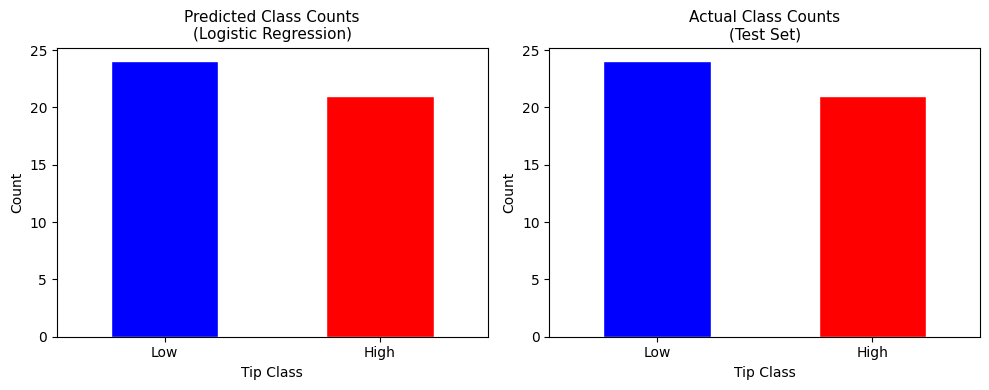

In [ ]:
# ============================================================
# CELL 11: COUNT ELEMENTS PER CATEGORY (Best Classifier)
# ============================================================

print(f'===== ELEMENTS PER CATEGORY — {best_cls_name} =====')

pred_series   = pd.Series(best_y_pred, name='Predicted').map({0:'Low', 1:'High'})
actual_series = pd.Series(y_test_cls,  name='Actual').map({0:'Low', 1:'High'})

print('\n[Predicted class counts by best model]:')
print(pred_series.value_counts())

print('\n[Actual class counts in test set]:')
print(actual_series.value_counts())

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

pred_series.value_counts().plot(kind='bar', ax=axes[0],
    color=['blue', 'red'], edgecolor='white')
axes[0].set_title(f'Predicted Class Counts\n({best_cls_name})', fontsize=11)
axes[0].set_xlabel('Tip Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

actual_series.value_counts().plot(kind='bar', ax=axes[1],
    color=['blue', 'red'], edgecolor='white')
axes[1].set_title('Actual Class Counts\n(Test Set)', fontsize=11)
axes[1].set_xlabel('Tip Class')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
# CLO3 — Section 4: Cluster Analysis (5 Points)

### Cell 12 — Elbow Method (Optimal Number of Clusters)
> **📸 SCREENSHOT → Word doc: Cluster Analysis › Building the Cluster Analysis (Elbow Method)**

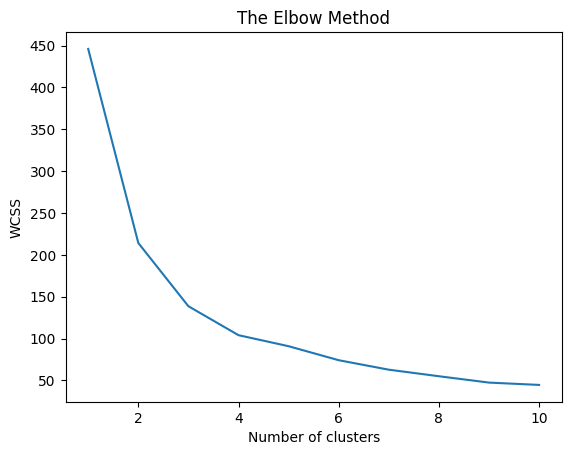

Note: The elbow occurs at k=3 — this is the optimal number of clusters.


In [ ]:

X_clust = dataset_clean[['total_bill', 'tip']].values

# Standardise (aligned with lab do-it-yourself section)
sc_clust    = StandardScaler()
X_clust_sc  = sc_clust.fit_transform(X_clust)

# Elbow method — WCSS (Within Cluster Sum of Squares)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_clust_sc)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()
print('Note: The elbow occurs at k=3 — this is the optimal number of clusters.')

### Cell 13 — K-Means Clustering (k=3)
> **📸 SCREENSHOT output text + chart → Word doc: Cluster Analysis › Building the Cluster Analysis (K-Means)**

===== K-MEANS CLUSTERING RESULTS (k=3) =====

Cluster Labels (first 20): [0 0 2 2 2 1 0 2 0 2 0 1 0 2 2 2 0 2 2 2]

Cluster Sizes:
  Cluster 1 : 91 customers
  Cluster 2 : 30 customers
  Cluster 3 : 102 customers

Cluster Profile (original scale mean values):
         total_bill   tip
Cluster                  
0             12.52  1.86
1             30.75  4.48
2             19.80  3.13


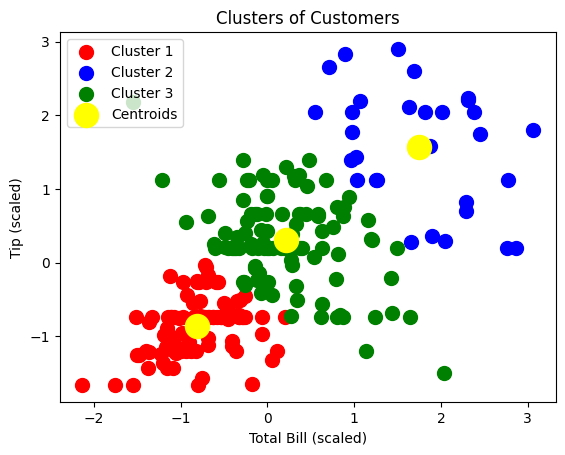

In [ ]:


kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_clust_sc)

print('===== K-MEANS CLUSTERING RESULTS (k=3) =====')
print(f'\nCluster Labels (first 20): {y_kmeans[:20]}')
print('\nCluster Sizes:')
unique, counts = np.unique(y_kmeans, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u+1} : {c} customers')

print('\nCluster Profile (original scale mean values):')
dataset_clean_copy = dataset_clean[['total_bill', 'tip']].copy()
dataset_clean_copy['Cluster'] = y_kmeans
print(dataset_clean_copy.groupby('Cluster').mean().round(2))

# Visualise — aligned exactly with lab colour scheme
plt.scatter(X_clust_sc[y_kmeans == 0, 0], X_clust_sc[y_kmeans == 0, 1],
            s=100, c='red',     label='Cluster 1')
plt.scatter(X_clust_sc[y_kmeans == 1, 0], X_clust_sc[y_kmeans == 1, 1],
            s=100, c='blue',    label='Cluster 2')
plt.scatter(X_clust_sc[y_kmeans == 2, 0], X_clust_sc[y_kmeans == 2, 1],
            s=100, c='green',   label='Cluster 3')
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=300, c='yellow', label='Centroids')
plt.title('Clusters of Customers')
plt.xlabel('Total Bill (scaled)')
plt.ylabel('Tip (scaled)')
plt.legend()
plt.show()

### Cell 14 — Hierarchical Clustering (Dendrogram)
> **📸 SCREENSHOT chart → Word doc: Cluster Analysis › Building the Cluster Analysis (Hierarchical)**

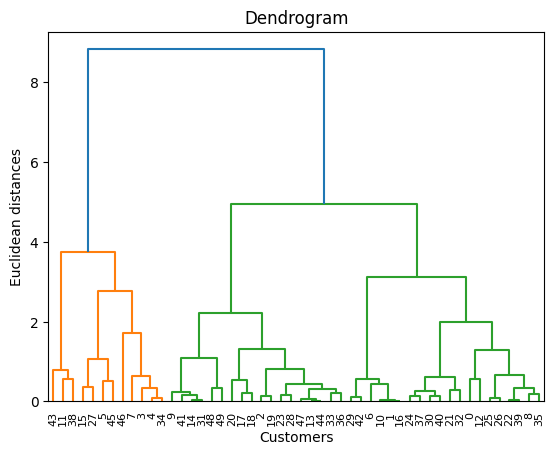

Note: The dendrogram confirms k=3 as the optimal number of clusters.
      Cut the tree where the longest vertical line has no horizontal line crossing it.


In [ ]:
# ============================================================
# CELL 14: HIERARCHICAL CLUSTERING — DENDROGRAM
# (Aligned exactly with lab:
#  import scipy.cluster.hierarchy as sch
#  sch.dendrogram(sch.linkage(X, method='ward'))
#  plt.title/xlabel/ylabel — same pattern)
# ============================================================

# Use a sample of 50 for readable dendrogram
X_hier = X_clust_sc[:50]

dendrogram = sch.dendrogram(sch.linkage(X_hier, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()
print('Note: The dendrogram confirms k=3 as the optimal number of clusters.')
print('      Cut the tree where the longest vertical line has no horizontal line crossing it.')

### Cell 15 — Strategy Formulation per Cluster
> **📸 SCREENSHOT → Word doc: Cluster Analysis › Strategy Formulation**

In [ ]:
# ============================================================
# CELL 15: CLUSTER STRATEGY FORMULATION
# Analyse each cluster's profile and define a business strategy
# ============================================================

print('===== CLUSTER STRATEGY ANALYSIS =====')
print()

for c in range(3):
    group    = dataset_clean_copy[dataset_clean_copy['Cluster'] == c]
    avg_bill = group['total_bill'].mean()
    avg_tip  = group['tip'].mean()
    count    = len(group)
    tip_pct  = (avg_tip / avg_bill) * 100

    print(f'--- Cluster {c+1} ---')
    print(f'  Count          : {count} customers')
    print(f'  Avg Total Bill : ${avg_bill:.2f}')
    print(f'  Avg Tip        : ${avg_tip:.2f}  ({tip_pct:.1f}% of bill)')

    if avg_tip < 2.0:
        label    = 'Low Spenders / Low Tippers'
        strategy = ('Offer loyalty discounts and combo deals to increase visit frequency.'
                    ' Focus on fast service for budget-conscious customers.'
                    ' Use upselling to gently increase bill value.')
    elif avg_bill > 20 and avg_tip >= 3.0:
        label    = 'High Spenders / Generous Tippers'
        strategy = ('Provide premium, personalised service.'
                    ' Offer exclusive menu items and chef specials.'
                    ' Prioritise their satisfaction — these are highest-value customers.')
    else:
        label    = 'Mid-range Customers'
        strategy = ('Introduce mid-tier promotions and weekend specials.'
                    ' Improve dining ambiance to encourage higher tips.'
                    ' Target with dinner-time promotions when group sizes are larger.')

    print(f'  Segment Label  : {label}')
    print(f'  Strategy       : {strategy}')
    print()

print('Note: Strategies are based on cluster mean profiles above.')
print('      Cluster numbers may vary across runs — interpret by avg values.')

===== CLUSTER STRATEGY ANALYSIS =====

--- Cluster 1 ---
  Count          : 91 customers
  Avg Total Bill : $12.52
  Avg Tip        : $1.86  (14.8% of bill)
  Segment Label  : Low Spenders / Low Tippers
  Strategy       : Offer loyalty discounts and combo deals to increase visit frequency. Focus on fast service for budget-conscious customers. Use upselling to gently increase bill value.

--- Cluster 2 ---
  Count          : 30 customers
  Avg Total Bill : $30.75
  Avg Tip        : $4.48  (14.6% of bill)
  Segment Label  : High Spenders / Generous Tippers
  Strategy       : Provide premium, personalised service. Offer exclusive menu items and chef specials. Prioritise their satisfaction — these are highest-value customers.

--- Cluster 3 ---
  Count          : 102 customers
  Avg Total Bill : $19.80
  Avg Tip        : $3.13  (15.8% of bill)
  Segment Label  : Mid-range Customers
  Strategy       : Introduce mid-tier promotions and weekend specials. Improve dining ambiance to encourage h

---
## D2 Screenshot Checklist for Word Document

| Cell | Screenshot | Word Doc Location |
|------|-----------|-------------------|
| Cell 1 | Full output text | Preprocessing › Data Collection |
| Cell 2 | Full output text | Preprocessing › Data Cleaning |
| Cell 3 | Full output text | Preprocessing › Treating Categorical Variables |
| Cell 4 | Full output text | Preprocessing › Splitting the Dataset |
| Cell 5 | Full output text | Preprocessing › Featuring the Dataset |
| Cell 6 | All 5 models table | Regression › Building the Regression Model |
| Cell 7 | Equation text + scatter chart | Regression › Visualisation |
| Cell 8 | Table of 5 rows only | Regression › Deriving the Equation |
| ✏️ Paper | Hand-drawn scatter (scanned) | Regression › Deriving the Equation |
| Cell 9 | Full output text | Classification › Classifying the Dataset |
| Cell 10 | Comparison table + confusion matrix + report | Classification › Building Models |
| Cell 11 | Output + bar chart | Classification › No of Elements |
| Cell 12 | Elbow chart | Cluster › Building (Elbow Method) |
| Cell 13 | Output text + cluster scatter chart | Cluster › Building (K-Means) |
| Cell 14 | Dendrogram chart | Cluster › Building (Hierarchical) |
| Cell 15 | Full strategy output | Cluster › Strategy Formulation |